<a href="https://colab.research.google.com/github/AdityaChoudhary-max/CODSOFT/blob/main/Spam_Message_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [173]:
import pandas as pd
import numpy as np

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

In [175]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [176]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [177]:
df = pd.read_csv("spam.csv", encoding='latin-1')

In [178]:
print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [179]:
print(df.shape)

(5572, 5)


In [180]:
df = df[['v1','v2']]
df.columns = ['label','message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [181]:
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [182]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

In [183]:
adi = df['message']
cho = df['label']

In [184]:
adi_train, adi_test, cho_train, cho_test = train_test_split(
    adi,
    cho,
    test_size=0.2,
    random_state=42
)

In [185]:
tfidf = TfidfVectorizer(stop_words='english')

adi_train_tfidf = tfidf.fit_transform(adi_train)

adi_test_tfidf = tfidf.transform(adi_test)

Naive Bayes

In [186]:
naba = MultinomialNB()

naba.fit(adi_train_tfidf, cho_train)

MultinomialNB()

In [187]:
naba_pred = naba.predict(adi_test_tfidf)

In [188]:
print(f"Naive Bayes Accuracy: {accuracy_score(cho_test, naba_pred) * 100:.2f}%")

Naive Bayes Accuracy: 96.68%


In [189]:
print(classification_report(cho_test, naba_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



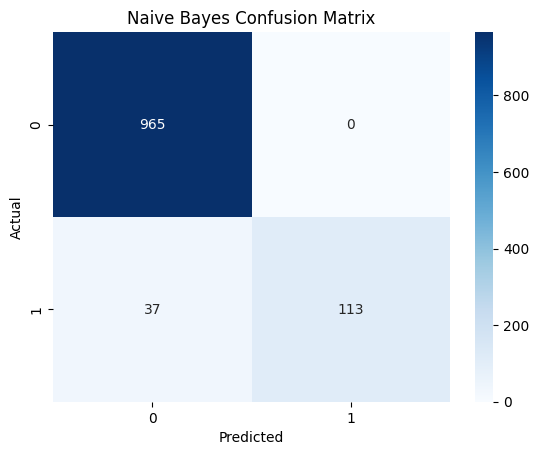

In [190]:
cm = confusion_matrix(cho_test, naba_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Logistic Regression

In [191]:
lr = LogisticRegression(max_iter=1000)

lr.fit(adi_train_tfidf, cho_train)

LogisticRegression(max_iter=1000)

In [192]:
lr_pred = lr.predict(adi_test_tfidf)

In [193]:
print(f"Logistic Regression Accuracy: {accuracy_score(cho_test, lr_pred) * 100:.2f}%")

Logistic Regression Accuracy: 95.25%


In [194]:
print(classification_report(cho_test, lr_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.97      0.67      0.79       150

    accuracy                           0.95      1115
   macro avg       0.96      0.83      0.88      1115
weighted avg       0.95      0.95      0.95      1115



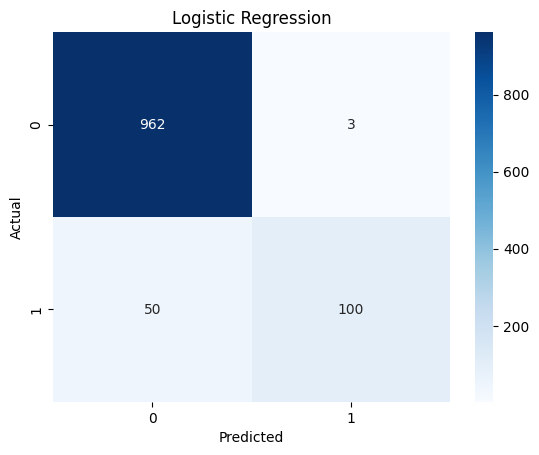

In [195]:
cm = confusion_matrix(cho_test, lr_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression")
plt.show()

Support Vector Machine (SVM)

In [196]:
svm = LinearSVC()

svm.fit(adi_train_tfidf, cho_train)

LinearSVC()

In [197]:
svm_pred = svm.predict(adi_test_tfidf)

In [198]:
print(f"SVM Accuracy: {accuracy_score(cho_test, svm_pred) * 100:.2f}%")

SVM Accuracy: 97.85%


In [199]:
print(classification_report(cho_test, svm_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       965
           1       0.96      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



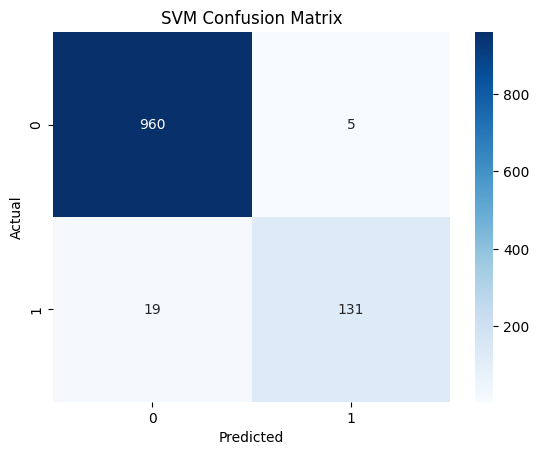

In [200]:
cm = confusion_matrix(cho_test, svm_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

Comparison

In [201]:
results = pd.DataFrame({
    "Model": [
        "Naya Bayse",
        "Logistic Regression",
        "Support Vector Machine"
    ],
    "Accuracy": [
        accuracy_score(cho_test, naba_pred)*100,
        accuracy_score(cho_test, lr_pred)*100,
        accuracy_score(cho_test, svm_pred)*100
    ]
})

print(results)

                    Model   Accuracy
0              Naya Bayse  96.681614
1     Logistic Regression  95.246637
2  Support Vector Machine  97.847534


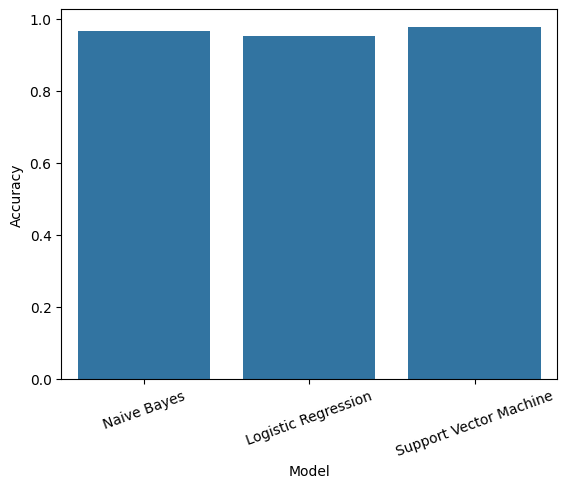

In [202]:
accuracy = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Logistic Regression",
        "Support Vector Machine"
    ],

    "Accuracy":[
        accuracy_score(cho_test, naba_pred),
        accuracy_score(cho_test, lr_pred),
        accuracy_score(cho_test, svm_pred)
    ]

})

sns.barplot(data=accuracy,
            x="Model",
            y="Accuracy")

plt.xticks(rotation=20)
plt.show()

In [203]:
print(results)

best_model = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

print("\nBest Performing Model :", best_model)

                    Model   Accuracy
0              Naya Bayse  96.681614
1     Logistic Regression  95.246637
2  Support Vector Machine  97.847534

Best Performing Model : Support Vector Machine


Prediction

In [205]:
message = input("Enter your SMS: ")

message_tfidf = tfidf.transform([message])

prediction = lr.predict(message_tfidf)
probability = lr.predict_proba(message_tfidf)

if prediction[0] == 1:
    print("\nPrediction: Spam Message")
    print("Confidence: {:.2f}%".format(probability[0][1] * 100))
else:
    print("\nPrediction: Legitimate Message")
    print("Confidence: {:.2f}%".format(probability[0][0] * 100))

Enter your SMS: Hi Bro, I'll be home by 8 PM. 

Prediction: Legitimate Message
Confidence: 96.82%


In [206]:
message = input("Enter your SMS: ")

message_tfidf = tfidf.transform([message])

prediction = lr.predict(message_tfidf)
probability = lr.predict_proba(message_tfidf)

if prediction[0] == 1:
    print("\nPrediction: Spam Message")
    print("Confidence: {:.2f}%".format(probability[0][1] * 100))
else:
    print("\nPrediction: Legitimate Message")
    print("Confidence: {:.2f}%".format(probability[0][0] * 100))

Enter your SMS: Congratulations! You have won a ₹50,000 gift voucher. Click here to claim 

Prediction: Spam Message
Confidence: 84.22%
